## Forecaster: XGBoost
The linear weighted composite from `forecaster.ipynb` fails on forward labels: test AUC barely
clears 0.5 and sits below the equal-weight baseline. The relationship between indicators and
60-day-ahead drawdowns is nonlinear and interactions matter.

Feature engineering from `feature_engineering.ipynb` identified raw ranks + 21d/63d momentum
(48 features) as the winning feature set, with 60d/8% as the optimal label configuration.
This notebook applies those findings: XGBoost trained on the momentum feature set with
`TimeSeriesSplit(gap=LOOKAHEAD)`. Metrics: AUC and Brier score. Baseline: equal-weight stress score.

In [1]:
import os
from itertools import product
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

N_JOBS = os.cpu_count()
print(f"using {N_JOBS} cores")

using 20 cores


### 1. Load data

In [2]:
try:
    df = pd.read_parquet("data/processed/stress_score.parquet")
    DOCS_PATH = Path("docs")
except FileNotFoundError:
    df = pd.read_parquet("../data/processed/stress_score.parquet")
    DOCS_PATH = Path("../docs")

df.index = pd.to_datetime(df.index)

INDICATOR_COLS = [
    "T10Y2Y",
    "T10Y3M",
    "T30Y10Y",
    "USALOLITOAASTSAM",
    "UMCSENT",
    "PERMIT",
    "NEWORDER",
    "ICSA",
    "DRCCLACBS",
    "BAMLH0A0HYM2",
    "XLK_XLV",
    "TLT",
    "HG=F",
    "CL=F",
    "EEM",
    "DX=F",
]

df = df.dropna(subset=INDICATOR_COLS)
print(f"{len(df)} rows, {df.index[0].date()} to {df.index[-1].date()}")

5014 rows, 2006-05-01 to 2026-03-19


### 2. Forward drawdown labels

In [3]:
DRAWDOWN_THRESHOLD = 0.08
LOOKAHEAD = 60

spy = df["SPY"]

future_min = spy[::-1].rolling(window=LOOKAHEAD, min_periods=LOOKAHEAD).min()[::-1].shift(-1)
future_drop = future_min / spy - 1

labels_fwd = pd.Series(np.nan, index=spy.index)
valid = future_min.notna()
labels_fwd[valid] = (future_drop[valid] <= -DRAWDOWN_THRESHOLD).astype(float)
labels_fwd = labels_fwd.dropna().astype(int)

print(f"{len(labels_fwd)} rows; {labels_fwd.sum()} forward drawdown events ({labels_fwd.mean():.1%})")

4954 rows; 938 forward drawdown events (18.9%)


### 3. Feature engineering
Raw ranks + 21d/63d momentum per indicator (48 features). Identified as the winning feature
set in `feature_engineering.ipynb`: momentum is the only family that consistently lifts AUC
over baseline; every other addition tested degraded performance at this sample size.

In [4]:
MOM_WINDOWS = [21, 63]
ranks = df[INDICATOR_COLS]

mom_frames = [ranks]
for w in MOM_WINDOWS:
    mom_frames.append(
        (ranks - ranks.shift(w)).rename(columns={c: f"{c}_mom{w}" for c in INDICATOR_COLS})
    )

features = pd.concat(mom_frames, axis=1)
X_data = features.loc[labels_fwd.index].dropna()
y_data = labels_fwd.loc[X_data.index]

n_pos = y_data.sum()
n_neg = len(y_data) - n_pos
scale_pos_weight = n_neg / n_pos

print(f"{X_data.shape[1]} features, {len(X_data)} rows")
print(f"{n_pos} forward drawdown events ({y_data.mean():.1%})")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

48 features, 4891 rows
938 forward drawdown events (19.2%)
scale_pos_weight: 4.21


### 4. Baseline (equal-weight stress score)
The baseline uses the equal-weight average of raw ranks, aligned to the momentum feature
index (which drops 63 warmup rows). This keeps the comparison honest: baseline and model
are evaluated on the same rows.

In [5]:
N = len(INDICATOR_COLS)
equal_score = ranks.loc[X_data.index].sum(axis=1) / N

tscv_base = TimeSeriesSplit(n_splits=5, gap=LOOKAHEAD)
baseline_aucs, baseline_briers = [], []

for _, test_idx in tscv_base.split(X_data):
    y_test = y_data.iloc[test_idx]
    eq_test = equal_score.iloc[test_idx]
    if y_test.nunique() < 2:
        continue
    baseline_aucs.append(roc_auc_score(y_test, eq_test))
    baseline_briers.append(brier_score_loss(y_test, eq_test))

print(f"equal-weight baseline  AUC: {np.mean(baseline_aucs):.4f}  Brier: {np.mean(baseline_briers):.4f}")

equal-weight baseline  AUC: 0.5348  Brier: 0.2295


### 5. XGBoost CV (base params)
Shallow trees (`max_depth=3`) and a low learning rate reduce overfitting on a dataset where
drawdown events are sparse and the signal is noisy. `scale_pos_weight` corrects for class imbalance.

In [ ]:
def run_xgb_cv(params, X, y, n_splits=5, gap=LOOKAHEAD):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    folds = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        model = XGBClassifier(**params, eval_metric="logloss", verbosity=0)
        model.fit(X_train, y_train)

        train_proba = model.predict_proba(X_train)[:, 1]
        test_proba = model.predict_proba(X_test)[:, 1]

        folds.append(
            {
                "fold": fold + 1,
                "test_start": X.index[test_idx[0]].date(),
                "test_end": X.index[test_idx[-1]].date(),
                "train_auc": roc_auc_score(y_train, train_proba),
                "auc": roc_auc_score(y_test, test_proba),
                "brier": brier_score_loss(y_test, test_proba),
            }
        )

    return folds


BASE_PARAMS = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "tree_method": "hist",
}

base_folds = run_xgb_cv(BASE_PARAMS, X_data, y_data)

print("XGBoost base CV:")
for f in base_folds:
    print(f"  fold {f['fold']} ({f['test_start']} to {f['test_end']}):  train AUC={f['train_auc']:.4f}  test AUC={f['auc']:.4f}  Brier={f['brier']:.4f}")
print()
print(f"mean train AUC: {np.mean([f['train_auc'] for f in base_folds]):.4f}")
print(f"mean test AUC:  {np.mean([f['auc'] for f in base_folds]):.4f}")
print(f"mean Brier:     {np.mean([f['brier'] for f in base_folds]):.4f}")

### 6. Hyperparameter sweep (refined)
Broad sweep identified depth=3 and low learning rate as the winning region. This sweep fixes
depth=3 and refines `n_estimators` and `learning_rate` with denser coverage around that region
(15 combinations). Selection criterion: `mean_auc - std_auc` to penalize variance.

In [ ]:
# Narrow grid around the winning region from the broad sweep (n_estimators=100, depth=3, lr=0.01).
# depth=3 is fixed; lr and n_estimators are refined with denser coverage.
PARAM_GRID = {
    "n_estimators": [75, 100, 150, 200, 300],
    "max_depth": [3],
    "learning_rate": [0.005, 0.01, 0.02],
}

param_combos = [
    {"n_estimators": n, "max_depth": d, "learning_rate": lr}
    for n, d, lr in product(PARAM_GRID["n_estimators"], PARAM_GRID["max_depth"], PARAM_GRID["learning_rate"])
]

print(f"{len(param_combos)} combinations")


def _sweep_job(combo, X, y):
    params = {
        **combo,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": n_neg / n_pos,
        "random_state": 42,
        "tree_method": "hist",
    }
    folds = run_xgb_cv(params, X, y)
    return {
        **combo,
        "mean_train_auc": np.mean([f["train_auc"] for f in folds]),
        "mean_auc": np.mean([f["auc"] for f in folds]),
        "mean_brier": np.mean([f["brier"] for f in folds]),
        "std_auc": np.std([f["auc"] for f in folds]),
    }


sweep_raw = Parallel(n_jobs=N_JOBS)(delayed(_sweep_job)(c, X_data, y_data) for c in param_combos)
sweep_results = sorted(sweep_raw, key=lambda r: r["mean_auc"], reverse=True)
print("sweep complete")

In [ ]:
print(f"{'n_est':>6}  {'depth':>5}  {'lr':>5}  {'AUC':>7}  {'std':>6}  {'Brier':>7}")
for r in sweep_results[:15]:
    print(
        f"{r['n_estimators']:>6}  {r['max_depth']:>5}  {r['learning_rate']:>5}  "
        f"{r['mean_auc']:>7.4f}  {r['std_auc']:>6.4f}  {r['mean_brier']:>7.4f}"
    )

In [9]:
# penalize variance: prefer stable AUC over lucky single-fold peaks
best = max(sweep_results, key=lambda r: r["mean_auc"] - r["std_auc"])
print(
    f"best: n_estimators={best['n_estimators']}  max_depth={best['max_depth']}  "
    f"learning_rate={best['learning_rate']}\n"
    f"      AUC={best['mean_auc']:.4f} +/- {best['std_auc']:.4f}  Brier={best['mean_brier']:.4f}"
)

best: n_estimators=100  max_depth=3  learning_rate=0.01
      AUC=0.6793 +/- 0.1174  Brier=0.2045


In [ ]:
best_idx = max(range(len(sweep_results)), key=lambda i: sweep_results[i]["mean_auc"] - sweep_results[i]["std_auc"])

gaps = [r["mean_train_auc"] - r["mean_auc"] for r in sweep_results]
test_aucs = [r["mean_auc"] for r in sweep_results]
lrs = [r["learning_rate"] for r in sweep_results]
n_ests = [r["n_estimators"] for r in sweep_results]

lr_values = sorted(set(lrs))
colors = {lr: c for lr, c in zip(lr_values, ["#1f77b4", "#ff7f0e", "#2ca02c"])}

fig, ax = plt.subplots(figsize=(7, 5))

for lr in lr_values:
    idx = [i for i, r in enumerate(sweep_results) if r["learning_rate"] == lr]
    ax.scatter(
        [gaps[i] for i in idx],
        [test_aucs[i] for i in idx],
        color=colors[lr],
        label=f"lr={lr}",
        s=60,
        zorder=3,
    )
    for i in idx:
        ax.annotate(
            str(n_ests[i]),
            (gaps[i], test_aucs[i]),
            textcoords="offset points",
            xytext=(5, 3),
            fontsize=7.5,
            color=colors[lr],
        )

ax.scatter(
    gaps[best_idx],
    test_aucs[best_idx],
    s=160,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    zorder=4,
    label="selected",
)

ax.set_xlabel("generalization gap (train AUC - test AUC)")
ax.set_ylabel("mean test AUC")
ax.set_title("Mean test AUC vs generalization gap\n(labels = n_estimators)")
ax.legend()
ax.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 7. Final CV with best params

In [11]:
BEST_PARAMS = {
    "n_estimators": best["n_estimators"],
    "max_depth": best["max_depth"],
    "learning_rate": best["learning_rate"],
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "tree_method": "hist",
}

best_folds = run_xgb_cv(BEST_PARAMS, X_data, y_data)

print("final CV (best params):")
for f in best_folds:
    print(f"  fold {f['fold']} ({f['test_start']} to {f['test_end']}):  AUC={f['auc']:.4f}  Brier={f['brier']:.4f}")
print()
print(f"baseline           AUC: {np.mean(baseline_aucs):.4f}  Brier: {np.mean(baseline_briers):.4f}")
print(f"XGBoost (tuned)    AUC: {np.mean([f['auc'] for f in best_folds]):.4f}  Brier: {np.mean([f['brier'] for f in best_folds]):.4f}")

final CV (best params):
  fold 1 (2009-10-16 to 2013-01-11):  AUC=0.6419  Brier=0.1638
  fold 2 (2013-01-14 to 2016-04-08):  AUC=0.8382  Brier=0.2833
  fold 3 (2016-04-11 to 2019-07-05):  AUC=0.7896  Brier=0.1892
  fold 4 (2019-07-08 to 2022-09-28):  AUC=0.7054  Brier=0.1910
  fold 5 (2022-09-29 to 2025-12-19):  AUC=0.4718  Brier=0.1996

baseline           AUC: 0.5348  Brier: 0.2295
XGBoost (tuned)    AUC: 0.6894  Brier: 0.2054


### 8. Feature importance

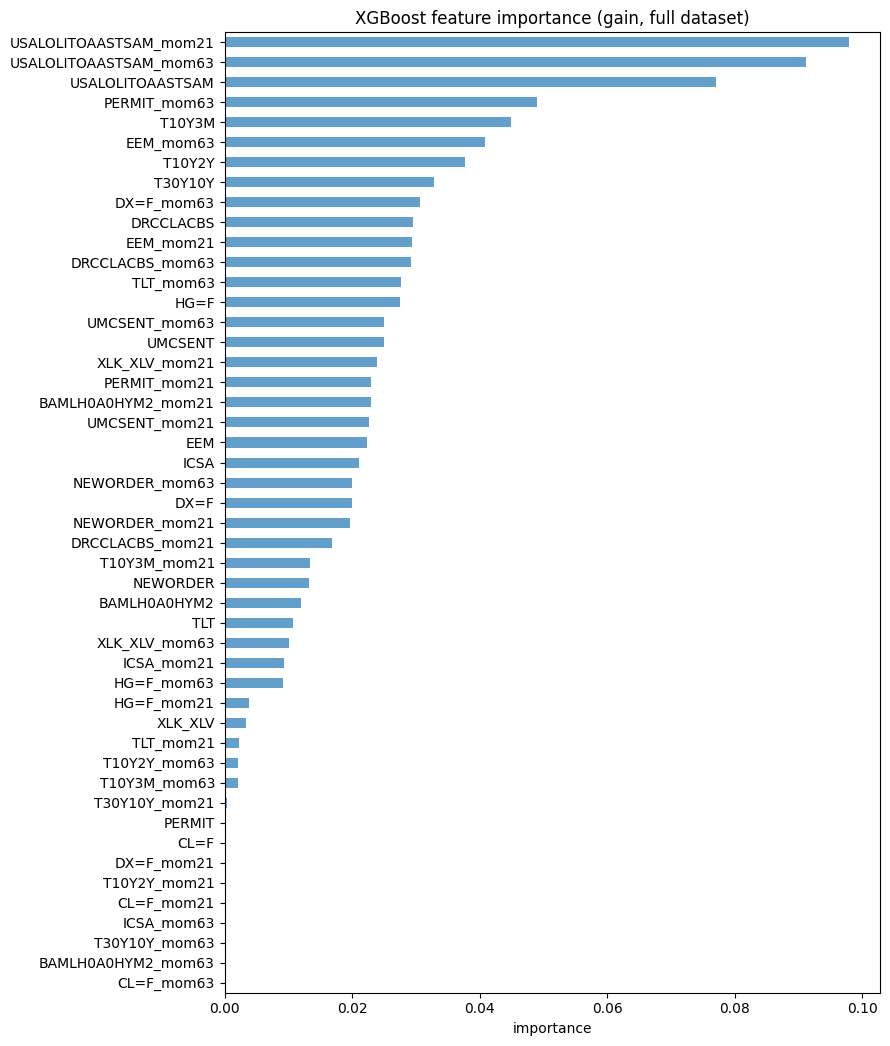

top 10:
USALOLITOAASTSAM_mom21    0.097914
USALOLITOAASTSAM_mom63    0.091216
USALOLITOAASTSAM          0.077139
PERMIT_mom63              0.048986
T10Y3M                    0.044876
EEM_mom63                 0.040858
T10Y2Y                    0.037775
T30Y10Y                   0.032905
DX=F_mom63                0.030649
DRCCLACBS                 0.029515


In [12]:
# fit on full dataset for feature importance — in-sample only
final_model = XGBClassifier(**BEST_PARAMS, eval_metric="logloss", verbosity=0)
final_model.fit(X_data, y_data)

importances = pd.Series(final_model.feature_importances_, index=X_data.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(4, len(importances) * 0.22)))
importances.plot.barh(ax=ax, color="#1f77b4", alpha=0.7)
ax.invert_yaxis()
ax.set_title("XGBoost feature importance (gain, full dataset)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

print("top 10:")
print(importances.head(10).to_string())

### 9. Probability visualization

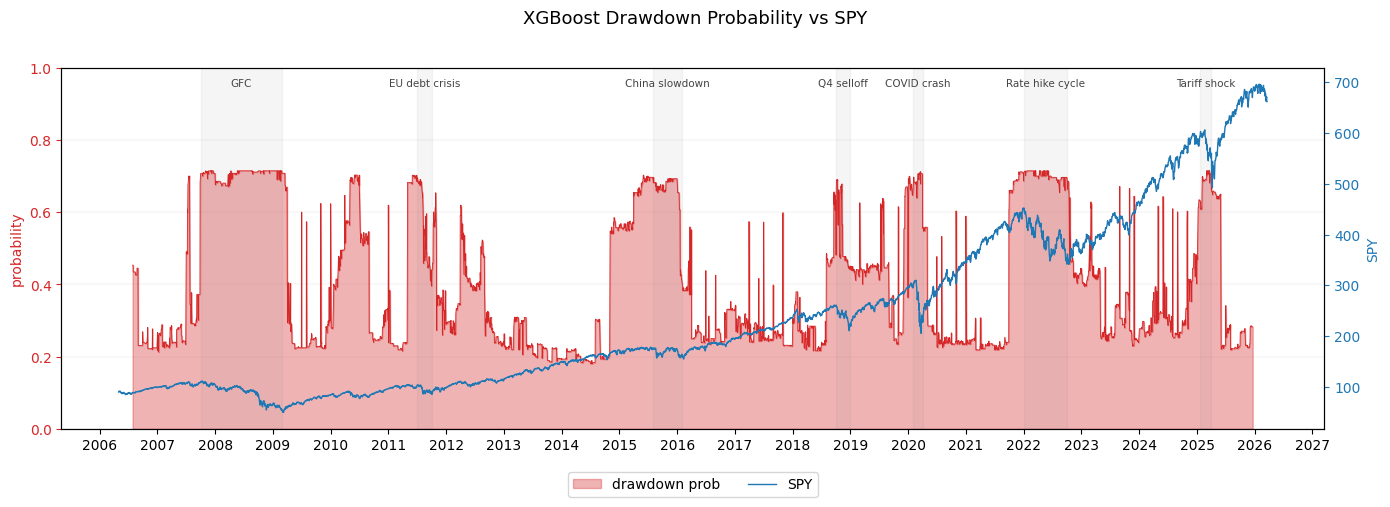

In [13]:
drawdown_prob = pd.Series(final_model.predict_proba(X_data)[:, 1], index=X_data.index)

STRESS_PERIODS = [
    ("2007-10-01", "2009-03-01", "GFC"),
    ("2011-07-01", "2011-10-01", "EU debt crisis"),
    ("2015-08-01", "2016-02-01", "China slowdown"),
    ("2018-10-01", "2018-12-31", "Q4 selloff"),
    ("2020-02-01", "2020-04-01", "COVID crash"),
    ("2022-01-01", "2022-10-01", "Rate hike cycle"),
    ("2025-01-20", "2025-04-01", "Tariff shock"),
]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(drawdown_prob.index, drawdown_prob, alpha=0.35, color="#d62728", label="drawdown prob")
ax1.plot(drawdown_prob.index, drawdown_prob, color="#d62728", linewidth=0.6)
ax2.plot(df.index, df["SPY"], color="#1f77b4", linewidth=1.0, label="SPY")

for start, end, label in STRESS_PERIODS:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="grey")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax1.text(
        mid, 0.97, label, ha="center", va="top", fontsize=7.5,
        color="#444444", transform=ax1.get_xaxis_transform(),
    )

ax1.set_ylabel("probability", color="#d62728")
ax2.set_ylabel("SPY", color="#1f77b4")
ax1.set_ylim(0, 1)
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.25)
ax1.set_axisbelow(True)
ax2.yaxis.grid(False)
ax1.tick_params(axis="y", colors="#d62728")
ax2.tick_params(axis="y", colors="#1f77b4")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

fig.suptitle("XGBoost Drawdown Probability vs SPY", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

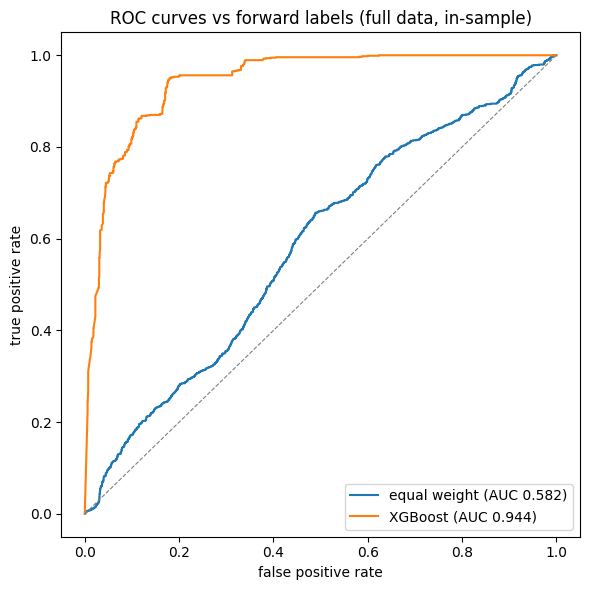

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))

for score, label, color in [
    (equal_score, f"equal weight (AUC {roc_auc_score(y_data, equal_score):.3f})", "#aec7e8"),
    (drawdown_prob, f"XGBoost (AUC {roc_auc_score(y_data, drawdown_prob):.3f})", "#d62728"),
]:
    fpr, tpr, _ = roc_curve(y_data, score)
    ax.plot(fpr, tpr, label=label)

ax.plot([0, 1], [0, 1], color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves vs forward labels (full data, in-sample)")
ax.legend()
plt.tight_layout()
plt.show()

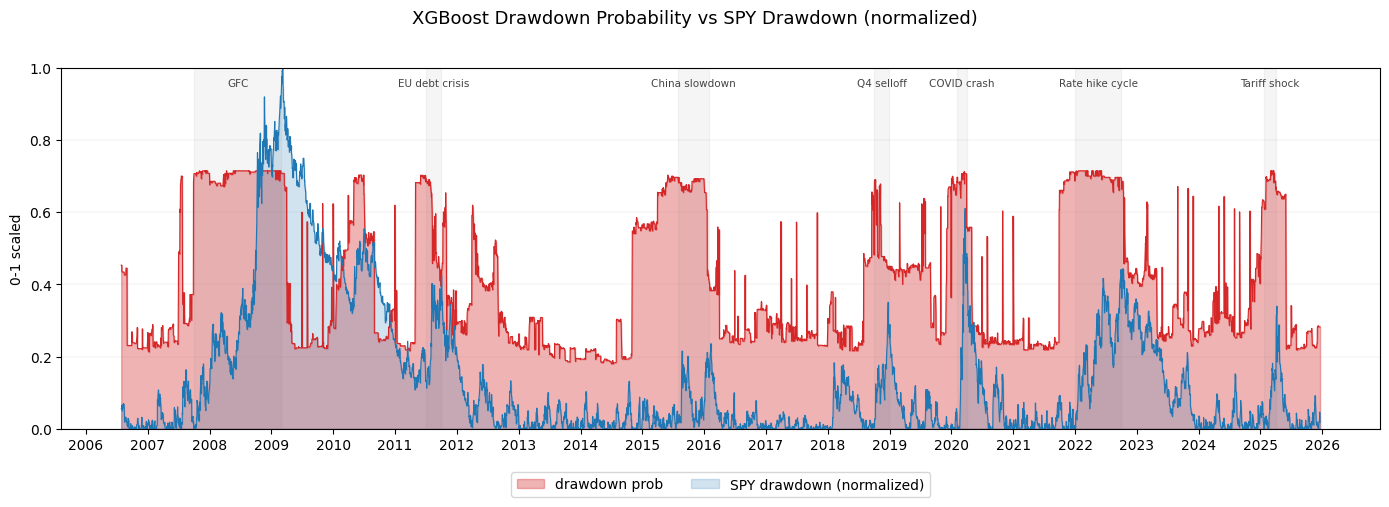

In [15]:
spy_dd = -(spy / spy.expanding().max() - 1)
spy_dd_norm = (spy_dd - spy_dd.min()) / (spy_dd.max() - spy_dd.min())
spy_dd_norm = spy_dd_norm.loc[X_data.index]

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(drawdown_prob.index, drawdown_prob, alpha=0.35, color="#d62728", label="drawdown prob")
ax.plot(drawdown_prob.index, drawdown_prob, color="#d62728", linewidth=0.8)

ax.fill_between(spy_dd_norm.index, spy_dd_norm, alpha=0.20, color="#1f77b4", label="SPY drawdown (normalized)")
ax.plot(spy_dd_norm.index, spy_dd_norm, color="#1f77b4", linewidth=0.8)

for start, end, label in STRESS_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="grey")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(
        mid, 0.97, label, ha="center", va="top", fontsize=7.5,
        color="#444444", transform=ax.get_xaxis_transform(),
    )

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylabel("0-1 scaled")
ax.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.25)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
fig.suptitle("XGBoost Drawdown Probability vs SPY Drawdown (normalized)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()